# T07 — Interactive paleo-Earth with Panel + pyGMT

**A scrollable time slider that re-renders a pyGMT figure each time you move it.**

## What this notebook produces

A **Panel widget** with a time slider running from 200 Ma to 0 Ma. The pyGMT global-Mollweide paleo-map under the slider re-renders to disk when the time changes; the browser then displays the cached PNG. A pre-render cell produces every 10 Myr frame up-front so slider interactions feel snappy.

**Audience**: both.  
**Difficulty**: ★★★.

## Learning objectives

- Wire a pyGMT renderer into a `panel` slider so the user can scrub reconstruction time interactively.
- Cache the model load outside the render callback so dragging the slider is fast.
- Recognise where `panel` belongs in the GPlately + pyGMT stack (interactive exploration; not animation export).


## Prerequisites and runtime

- **Plate model**: Zahirovic 2022.
- **Time range**: 0–250 Ma slider.
- **Python**: `gplately`, `pygmt`, `panel`, `pygplates`.
- **Runtime**: < 30 s to render the first frame; each slider drag re-renders in ~1 s.
- **Display**: needs a notebook frontend that supports `panel` widgets (JupyterLab or Notebook).


In [5]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — install hint
# Requires panel >= 1.0 — `conda install -c conda-forge panel`
import panel as pn
pn.extension()
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration

User-tunable choices for this notebook. Edit the values below to change the model, snapshot time, region, or anchor plate without hunting through downstream code.


In [6]:
# === USER CONFIGURATION =====================================================
MODEL_NAME           = "Zahirovic2022"
TIME_MIN_MA          = 0.0           # Ma — slider lower bound
TIME_MAX_MA          = 250.0         # Ma — slider upper bound
TIME_STEP_MA         = 5.0           # Ma — slider tick
DEFAULT_TIME_MA      = 50.0          # Ma — initial slider value
ANCHOR_PLATE_ID      = 0
# ============================================================================


In [7]:
# Cell 2 — pre-render frames to disk (fast slider afterwards)
import gplately, pygmt
from pathlib import Path
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

# Suite-wide tutorial style: bigger panel titles, 1cm gap between figures.
pygmt.config(FONT_TITLE="18p", FONT_LABEL="18p",
             FONT_ANNOT_PRIMARY="14p")

pmm = PlateModelManager(); model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons())
engine = gplately.PygmtPlotEngine()

CACHE = Path("./panel_cache"); CACHE.mkdir(exist_ok=True)
for t in range(0, 201, 10):
    f = CACHE / f"frame_{t:03d}.png"
    if f.exists(): continue
    gplot = gplately.PlotTopologies(plate_reconstruction=recon,
        coastlines=model.get_coastlines(),
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(), time=t)
    fig = pygmt.Figure()
    fig.basemap(region="d", projection="W0/16c", frame=["af", f'+t{t} Ma'])
    engine.plot_geo_data_frame(fig, gplot.get_continents(),
                               fill="gray95", pen="0.2p,gray30")
    engine.plot_geo_data_frame(fig, gplot.get_coastlines(), pen="0.3p,gray20")
    # Continuous plate-boundary backbone (incl. "other" segments
    # that aren't classified as ridge / transform / subduction — these are
    # the connection points that would otherwise leave gaps in the network).
    # Draw this FIRST so ridges, transforms and trenches render on top with
    # their distinctive colours. Pattern follows the Dixon A24 reference.
    engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(),
                               pen="0.5p,gray50")

    (_tl, _tr) = gplot.get_subduction_direction()
    engine.plot_subduction_zones(fig, _tl, _tr, color="blue")
    fig.text(text=f"{t:.0f} Ma  ({MODEL_NAME})",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    fig.savefig(f, dpi=100)
print("cached.")

cached.


Preloaded 21 frames


Column
    [0] PNG(bytes, width=700)
    [1] IntSlider(end=200, label='Age (Ma)', name='Age (Ma)', step=10)
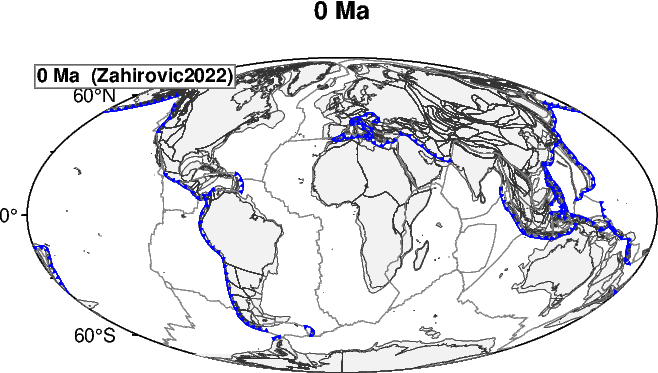

In [8]:
# Cell 3 — panel slider
#
# Preload every frame's PNG bytes into a dict in memory, then mutate
# a single `pn.pane.PNG`'s `.object` attribute on every slider change
# via `slider.param.watch`. This is the most reliable Panel pattern
# for a file-backed image switcher — it sidesteps:
#  • file-vs-URL caching at the browser layer (we never reference a
#    file path; the image content is updated in-memory)
#  • Panel's lazy reactive re-execution (`watch` fires synchronously)
#  • disk I/O cost on every drag of the slider
import io
from pathlib import Path

# Preload all frames as bytes so slider updates are instant.
frame_bytes = {}
for _t in range(0, 201, 10):
    _path = CACHE / f"frame_{_t:03d}.png"
    if _path.exists():
        frame_bytes[_t] = _path.read_bytes()
print(f"Preloaded {len(frame_bytes)} frames")

slider = pn.widgets.IntSlider(
    name="Age (Ma)", start=0, end=200, step=10, value=0,
)
image_pane = pn.pane.PNG(object=frame_bytes[0], width=700)

def _update_image(event):
    if event.new in frame_bytes:
        image_pane.object = frame_bytes[event.new]

slider.param.watch(_update_image, "value")

pn.Column(image_pane, slider)

## Extend this

- **Switch the plate model.** Replace `Zahirovic2022` with another `plate_model_manager` model (e.g. `Cao2024` for 1.8 Ga coverage) and re-render the cached frames into a new cache directory.
- **Add a second slider.** Lay out an additional `pn.widgets.Select` to switch between plate models or projection presets and update the basemap accordingly.
- **Wider time span.** Drop the slider step from 10 Myr to 5 Myr for a smoother scrub at the cost of a longer pre-render.

## References

- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geosci. Data J.* 11, 3-10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J., Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679085
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochem. Geophys. Geosys.* 20, 5556-5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing published plate-reconstruction models. *Zenodo*. https://github.com/michaelchin/plate-model-manager
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Müller, R.D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9, 371-383. https://doi.org/10.1002/gdj3.146
- Holoviz authors (2024). Panel: A high-level app and dashboarding solution for Python. https://panel.holoviz.org